# Ajustando um modelo para usina

In [21]:
import pandas as pd

dados = pd.read_csv('usina.csv')
dados.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

x = dados[['AT', 'V', 'AP', 'RH']]
y = dados['PE']

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size=0.3, random_state=230)
treino_x = sm.add_constant(treino_x)
treino_x.head()

,const,AT,V,AP,RH
3522,1.0,11.09,40.43,1025.47,74.97
4271,1.0,14.20,40.92,1022.26,71.71
6811,1.0,7.03,41.74,1021.92,86.44
1801,1.0,23.82,48.92,1010.48,44.45
8036,1.0,16.16,52.05,1013.19,75.37


In [23]:
modelo = sm.OLS(treino_y, treino_x).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:32:49   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.0

In [27]:
dados.columns
explicativas = ['AT', 'V', 'AP', 'RH', 'const']

In [28]:
# VIF 1
vif = pd.DataFrame()
vif['variavel'] = explicativas
vif['vif'] = [variance_inflation_factor(treino_x[explicativas], i) for i in range(len(explicativas))]
vif

,variavel,vif
0,AT,6.034363
1,V,3.954998
2,AP,1.468530
3,RH,1.717508
4,const,44603.788615


In [29]:
residuos = modelo.resid
y_previsto_treino = modelo.predict(treino_x[explicativas])

<Axes: title={'center': 'Resíduos x Previsão'}, xlabel='Preço da Casa - Previsão', ylabel='Resíduos'>

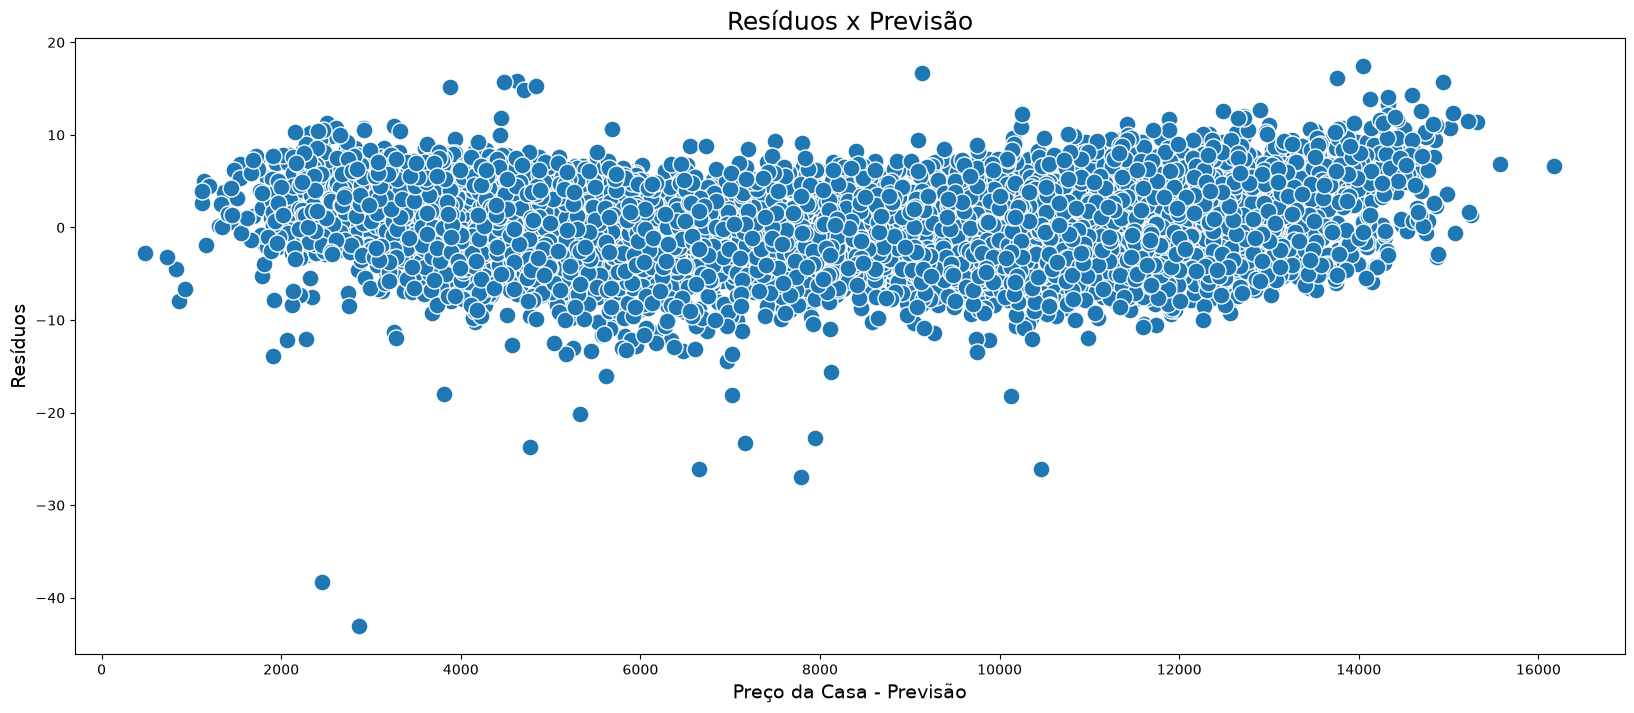

In [30]:
import seaborn as sns

ax = sns.scatterplot(x=y_previsto_treino, y=residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Resíduos x Previsão', fontsize=18)
ax.set_xlabel('Preço da Casa - Previsão', fontsize=14)
ax.set_ylabel('Resíduos', fontsize=14)
ax